# Lab 4 - RNN-based Named Entity Recognition

**Topic:** BIO-tagging NER with RNN / GRU / LSTM encoders (uni- and bi-directional), preprocessing ablations
(lower-casing, digit normalisation, `<UNK>` handling, casing feature, character CNN), model capacity, and
error analysis on a held-out split.

**Sections**
1. Data and the held-out split
2. Experiment A - RNN / GRU / LSTM, uni- vs bi-directional
3. Experiment B - preprocessing
4. Experiment C - capacity
5. Results table and plot
6. Per-type report, confusion matrix and error taxonomy (best model)
7. `--text` demo

**Kernel:** Speech Lab (.venv)

All model, data and metric code is imported from `lab 4/solution/rnn_ner.py` and `lab 4/solution/ner_dataset.py`,
which are not modified. Notebook outputs (CSV, PNG) are written to `notebooks/lab4_outputs/`; the earlier run in
`lab 4/solution/results/` is only read for comparison.

## Setup

Imports, paths and the **`RUN_FULL` switch**.
`RUN_FULL = False` (default) uses the `--quick` data sizes and epochs, so the notebook runs in minutes.
`RUN_FULL = True` uses the full settings of `python rnn_ner.py` (15 models, roughly 20-30 minutes on CPU).
To switch: edit `RUN_FULL` in this cell, then *Restart & Run All*.

In [1]:
%matplotlib inline
import os, sys, re, time
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import torch

# the notebook lives in notebooks/; the repo root is the folder that contains "lab 4/solution"
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab 4" / "solution").exists())
SOL = ROOT / "lab 4" / "solution"
assert SOL.exists(), SOL
OUT_DIR = ROOT / "notebooks" / "lab4_outputs"      # notebook outputs; repo results/ is never written
OUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(SOL))
os.chdir(SOL)

# ---- the switch ------------------------------------------------------------------------------
RUN_FULL = False      # False: --quick settings (a few minutes)   True: full settings (~20-30 min on CPU)

import rnn_ner                       # real module; its main() is NOT called (steps are replicated per cell)
from ner_dataset import load_synthetic, read_conll
from rnn_ner import get_entities, evaluate, error_taxonomy, predict, run_experiment, experiments, fmt

N_SIZES = (2000, 400, 800) if RUN_FULL else (800, 200, 400)   # train / dev / test sentences (as in main())
EPOCHS = 10 if RUN_FULL else 6                                 # as in main()
MODE = "full" if RUN_FULL else "quick"


def html_table(headers, rows, digits=3):
    """Small HTML table helper (pandas is not installed in the Speech Lab venv)."""
    def cell(x):
        if isinstance(x, float):
            return "n/a" if x != x else f"{x:.{digits}f}"
        if isinstance(x, int):
            return f"{x:,}"
        return str(x)
    head = "".join(f"<th style='text-align:left;padding:2px 8px'>{h}</th>" for h in headers)
    body = "".join(
        "<tr>" + "".join(f"<td style='text-align:left;padding:2px 8px'>{cell(x)}</td>" for x in r) + "</tr>"
        for r in rows)
    return HTML(f"<table><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>")


print(f"python {sys.version.split()[0]} | torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")
print(f"mode={MODE}  RUN_FULL={RUN_FULL}  sizes(train/dev/test)={N_SIZES}  epochs={EPOCHS}  seed=7")
print(f"repo: {ROOT}")

python 3.13.12 | torch 2.14.1+cpu | cuda available: False
mode=quick  RUN_FULL=False  sizes(train/dev/test)=(800, 200, 400)  epochs=6  seed=7
repo: U:\VITc\speech lab


## 1. Data and the held-out split

The corpus is synthetic (`ner_dataset.py`). 30 % of first names, surnames, locations and organisations, and
10 of the 50 sentence templates, are reserved for dev/test only. Test years (2023-2030) never occur in training
(2012-2022), and about 12 % of sentences are lower-cased to imitate ASR output. The cells below show the data and
how many test entities were never seen in training.

In [2]:
train, dev, test = load_synthetic(*N_SIZES)
tags = sorted({t for _, ts in train + dev + test for t in ts}, key=lambda t: (t != "O", t[2:], t))
types = sorted({t[2:] for t in tags if t != "O"})
seen = {" ".join(toks[s:e + 1]).lower() for toks, ts in train for _, s, e in get_entities(ts)}
MEAN_LEN = np.mean([len(t) for t, _ in train])

print(f"sentences  train/dev/test: {len(train)}/{len(dev)}/{len(test)}   mean length (train): {MEAN_LEN:.1f} tokens")
print(f"entity types: {types}")
print(f"tag set ({len(tags)}): {tags}")

split_counts = {name: Counter(e[0] for _, ts in split for e in get_entities(ts))
                for name, split in [("train", train), ("dev", dev), ("test", test)]}
print("\nEntity mentions per type:")
display(html_table(["type", "train", "dev", "test"],
                   [[t, split_counts["train"][t], split_counts["dev"][t], split_counts["test"][t]] for t in types]
                   + [["total", sum(split_counts["train"].values()), sum(split_counts["dev"].values()),
                       sum(split_counts["test"].values())]]))

test_ents = [" ".join(toks[s:e + 1]).lower() for toks, ts in test for _, s, e in get_entities(ts)]
n_unseen = sum(x not in seen for x in test_ents)
print(f"\ndistinct entity surface forms seen in training: {len(seen)}")
print(f"test entity mentions: {len(test_ents)}   never seen in training: {n_unseen} ({n_unseen / len(test_ents):.1%})")
print("most frequent unseen test entities:", Counter(x for x in test_ents if x not in seen).most_common(8))

def show(toks, ts):
    return " ".join(f"{w}/{t}" if t != "O" else w for w, t in zip(toks, ts))

print("\nTraining examples (word/TAG):")
for toks, ts in train[:3]:
    print("  " + show(toks, ts))
print("\nTest examples (held-out names and templates):")
for toks, ts in test[:3]:
    print("  " + show(toks, ts))

sentences  train/dev/test: 800/200/400   mean length (train): 10.0 tokens
entity types: ['DATE', 'LOC', 'ORG', 'PER']
tag set (9): ['O', 'B-DATE', 'I-DATE', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-PER', 'I-PER']

Entity mentions per type:


type,train,dev,test
DATE,558,135,261
LOC,593,153,288
ORG,508,136,266
PER,485,118,257
total,"2,144",542,"1,072"



distinct entity surface forms seen in training: 829
test entity mentions: 1072   never seen in training: 621 (57.9%)
most frequent unseen test entities: [('japan', 8), ('australia', 8), ('china', 8), ('hyderabad', 8), ('zomato', 7), ('nepal', 7), ('kolkata', 7), ('cognizant', 6)]

Training examples (word/TAG):
  Call Venkatesh/B-PER Jones/I-PER and tell him the report is due last/B-DATE month/I-DATE
  Heavy rain was reported in Rajasthan/B-LOC on tomorrow/B-DATE
  The office of Hindustan/B-ORG Unilever/I-ORG in Amazon/B-LOC Basin/I-LOC will remain closed 4/B-DATE October/I-DATE 2017/I-DATE

Test examples (held-out names and templates):
  Navigate to Lotus/B-ORG Logistics/I-ORG in Sydney/B-LOC
  find hotels near mangalore/B-LOC for yesterday/B-DATE
  Send a message to Arjun/B-PER Krishnan/I-PER saying the demo is on last/B-DATE month/I-DATE


## 2. Experiment A - RNN / GRU / LSTM, uni- vs bi-directional

All models use the raw words (no lower-casing, no char or casing features), 100-d word embeddings, hidden size 128,
one layer, dropout 0.3, Adam (lr 2e-3). The epoch with the best dev F1 is kept, and the test set is scored once.
The **sweep cell** below trains all 15 configurations (groups A, B and C) with the same `run_experiment()` calls
as `rnn_ner.py`; sections 2-4 display their own group from it. This is the only cell that trains models.

In [3]:
# =============================================================================================
# SWEEP: all 15 configurations of Experiments A, B and C (rnn_ner.experiments()).
#   RUN_FULL = False (setup cell) -> --quick data and epochs, a few minutes on CPU
#   RUN_FULL = True  (setup cell) -> full data and epochs, roughly 20-30 minutes on CPU
# Every configuration is trained by rnn_ner.run_experiment() with seed 7.
# =============================================================================================
print(f"Sweep mode: {MODE.upper()} (RUN_FULL={RUN_FULL})")
rows, best = [], None
t_sweep = time.time()
for k, cfg in enumerate(experiments(), 1):
    res, model, pre, preds, maps = run_experiment(cfg, train, dev, test, tags, types, seen, EPOCHS, seed=7)
    rows.append((cfg, res))
    print(f"[{k:2d}] {cfg['name']:<44} test-F1={res['F1']:.4f}  unseen-R={fmt(res['R_unseen'])}  "
          f"({res['time']:.0f}s, best epoch {res['best_epoch']})")
    if best is None or res["dev_F1"] > best["res"]["dev_F1"]:  # best model chosen on DEV F1, as in the script
        best = dict(cfg=cfg, res=res, model=model, pre=pre, preds=preds, maps=maps)
print(f"Sweep finished in {time.time() - t_sweep:.0f}s.  Best by dev F1: {best['cfg']['name']} "
      f"(dev F1 {best['res']['dev_F1']:.4f})")

COLS = ["group", "configuration", "precision", "recall", "f1", "macro_f1", "token_acc", "recall_seen",
        "recall_unseen", "f1_lowercased", "dev_f1", "best_epoch", "train_time_s", "params"]


def results_records(sel=lambda cfg: True):
    """One dict per configuration, keyed by the column names of results/experiments.csv."""
    out = []
    for cfg, r in rows:
        if sel(cfg):
            vals = [cfg["group"], cfg["name"], r["P"], r["R"], r["F1"], r["macroF1"], r["tok_acc"],
                    r["R_seen"], r["R_unseen"], r["F1_lowercased"], r["dev_F1"], r["best_epoch"],
                    round(r["time"], 1), r["params"]]
            out.append(dict(zip(COLS, vals)))
    return out


def pick(records, keys):
    return [[rec[k] for k in keys] for rec in records]


R_by_name = {c["name"]: r for c, r in rows}


def delta(a, b, key="F1"):
    return R_by_name[a][key] - R_by_name[b][key]


def verdict(d):
    return "helped" if d > 0.005 else "hurt" if d < -0.005 else "made no clear difference"


SHOW_COLS = ["configuration", "precision", "recall", "f1", "macro_f1", "token_acc", "recall_seen",
             "recall_unseen", "f1_lowercased", "best_epoch", "params"]


def table_for(sel, keys=SHOW_COLS):
    return html_table(keys, pick(results_records(sel), keys))

Sweep mode: QUICK (RUN_FULL=False)


[ 1] RNN                                          test-F1=0.7742  unseen-R=0.647  (8s, best epoch 6)


[ 2] BiRNN                                        test-F1=0.8004  unseen-R=0.671  (12s, best epoch 5)


[ 3] GRU                                          test-F1=0.7790  unseen-R=0.638  (11s, best epoch 5)


[ 4] BiGRU                                        test-F1=0.8151  unseen-R=0.668  (18s, best epoch 6)


...

[11] BiLSTM + char-CNN                            test-F1=0.8883  unseen-R=0.820  (23s, best epoch 6)


[12] BiLSTM + ALL preprocessing + char + case     test-F1=0.9234  unseen-R=0.913  (11s, best epoch 6)


[13] 2-layer BiLSTM (full pipeline)               test-F1=0.9164  unseen-R=0.894  (1063s, best epoch 5)


[14] BiLSTM hidden=32 (full pipeline)             test-F1=0.8035  unseen-R=0.767  (6s, best epoch 6)


[15] BiRNN (full pipeline)                        test-F1=0.9082  unseen-R=0.871  (6s, best epoch 5)
Sweep finished in 1274s.  Best by dev F1: 2-layer BiLSTM (full pipeline) (dev F1 0.9280)


### Experiment A results

Gated cells (LSTM / GRU) against the vanilla RNN, and bidirectional against unidirectional models.

In [4]:
display(table_for(lambda c: c["group"].startswith("A")))

d_bi = np.mean([delta("BiLSTM", "LSTM"), delta("BiGRU", "GRU"), delta("BiRNN", "RNN")])
print("* Gated cells (LSTM/GRU) vs vanilla RNN: "
      f"LSTM-RNN = {delta('LSTM', 'RNN'):+.3f} F1 (LSTM {verdict(delta('LSTM', 'RNN'))}), "
      f"GRU-RNN = {delta('GRU', 'RNN'):+.3f} F1 (GRU {verdict(delta('GRU', 'RNN'))}). "
      "Gates fight vanishing gradients; the benefit grows with sentence length. "
      f"Mean sentence length here is {MEAN_LEN:.1f} tokens, so a modest gap is expected.\n")
print("* Bidirectionality: "
      f"BiLSTM-LSTM = {delta('BiLSTM', 'LSTM'):+.3f}, BiGRU-GRU = {delta('BiGRU', 'GRU'):+.3f}, "
      f"BiRNN-RNN = {delta('BiRNN', 'RNN'):+.3f} -> {verdict(d_bi)}. A left-to-right model must tag "
      "'Apex' before seeing 'Airlines'; the backward pass supplies that right context.")

configuration,precision,recall,f1,macro_f1,token_acc,recall_seen,recall_unseen,f1_lowercased,best_epoch,params
RNN,0.805,0.745,0.774,0.753,0.897,0.880,0.647,0.683,6,"95,001"
BiRNN,0.837,0.767,0.800,0.785,0.903,0.898,0.671,0.674,5,"125,593"
GRU,0.820,0.742,0.779,0.760,0.894,0.885,0.638,0.698,5,"153,881"
BiGRU,0.859,0.775,0.815,0.796,0.902,0.922,0.668,0.736,6,"243,353"
LSTM,0.797,0.763,0.780,0.766,0.898,0.867,0.688,0.664,6,"183,321"
BiLSTM,0.827,0.801,0.814,0.803,0.909,0.916,0.718,0.743,6,"302,233"


* Gated cells (LSTM/GRU) vs vanilla RNN: LSTM-RNN = +0.006 F1 (LSTM helped), GRU-RNN = +0.005 F1 (GRU made no clear difference). Gates fight vanishing gradients; the benefit grows with sentence length. Mean sentence length here is 10.0 tokens, so a modest gap is expected.

* Bidirectionality: BiLSTM-LSTM = +0.034, BiGRU-GRU = +0.036, BiRNN-RNN = +0.026 -> helped. A left-to-right model must tag 'Apex' before seeing 'Airlines'; the backward pass supplies that right context.


## 3. Experiment B - preprocessing

Each variant changes one thing relative to the plain BiLSTM: lower-casing the whole input, digit normalisation
(`2027` -> `0000`), `<UNK>` handling (min-frequency 2 plus word dropout 0.1), lower-cased word lookup with an
8-d casing feature, and a character CNN. The last row combines all of them. Read F1 together with recall on
unseen entities and F1 on lower-cased sentences.

In [5]:
display(table_for(lambda c: c["group"].startswith("B") or c["name"] == "BiLSTM"))

d_low = delta("BiLSTM + lowercase input", "BiLSTM")
d_dig = delta("BiLSTM + digit normalisation", "BiLSTM")
d_unk = delta("BiLSTM + UNK (min_freq=2, word-dropout)", "BiLSTM")
d_unk_r = delta("BiLSTM + UNK (min_freq=2, word-dropout)", "BiLSTM", "R_unseen")
d_case = delta("BiLSTM + lower words + casing feature", "BiLSTM")
d_char = delta("BiLSTM + char-CNN", "BiLSTM")
d_char_r = delta("BiLSTM + char-CNN", "BiLSTM", "R_unseen")
d_full = delta("BiLSTM + ALL preprocessing + char + case", "BiLSTM")
print(f"* Lower-casing the whole input: {d_low:+.3f} F1 -> {verdict(d_low)}. It merges 'Chennai'/'chennai' "
      "(fewer OOV words, and lower-cased ASR-style sentences share embeddings) but discards capitalisation, "
      "the strongest English NER cue. Compare with the casing-feature run, which keeps both benefits.\n")
print(f"* Digit normalisation: {d_dig:+.3f} F1 -> {verdict(d_dig)}. Test years (2023-2030) never occur in "
      "training; as '0000' they map to a known token, which helps DATE spans.\n")
print(f"* <UNK> handling (min_freq=2 + word dropout): {d_unk:+.3f} F1, unseen-entity recall {d_unk_r:+.3f} -> "
      f"{verdict(d_unk)}. Without it the <UNK> vector is never trained, so every unseen name gets a random embedding.\n")
print(f"* Lower-cased word lookup + casing feature: {d_case:+.3f} F1 -> {verdict(d_case)}. Vocabulary sparsity "
      "drops while an explicit 8-d casing embedding (Title / UPPER / lower / digit) keeps the capitalisation signal.\n")
print(f"* Character-level CNN: {d_char:+.3f} F1, unseen-entity recall {d_char_r:+.3f} -> {verdict(d_char)}. "
      "Sub-word patterns (-abad, -pur, 'Technologies', digit shapes) transfer to names never seen in training.\n")
print(f"* All preprocessing + char + case combined: {d_full:+.3f} F1 over the raw BiLSTM.")

configuration,precision,recall,f1,macro_f1,token_acc,recall_seen,recall_unseen,f1_lowercased,best_epoch,params
BiLSTM,0.827,0.801,0.814,0.803,0.909,0.916,0.718,0.743,6,"302,233"
BiLSTM + lowercase input,0.873,0.886,0.880,0.878,0.948,0.931,0.853,0.877,5,"282,733"
BiLSTM + digit normalisation,0.858,0.808,0.832,0.824,0.926,0.925,0.723,0.717,6,"297,333"
"BiLSTM + UNK (min_freq=2, word-dropout)",0.867,0.882,0.874,0.874,0.949,0.922,0.852,0.775,6,"291,933"
BiLSTM + lower words + casing feature,0.910,0.897,0.904,0.902,0.955,0.942,0.865,0.826,6,"290,981"
BiLSTM + char-CNN,0.902,0.875,0.888,0.884,0.949,0.951,0.820,0.805,6,"359,873"
BiLSTM + ALL preprocessing + char + case,0.909,0.938,0.923,0.923,0.969,0.973,0.913,0.913,6,"343,151"


* Lower-casing the whole input: +0.066 F1 -> helped. It merges 'Chennai'/'chennai' (fewer OOV words, and lower-cased ASR-style sentences share embeddings) but discards capitalisation, the strongest English NER cue. Compare with the casing-feature run, which keeps both benefits.

* Digit normalisation: +0.018 F1 -> helped. Test years (2023-2030) never occur in training; as '0000' they map to a known token, which helps DATE spans.

* <UNK> handling (min_freq=2 + word dropout): +0.060 F1, unseen-entity recall +0.134 -> helped. Without it the <UNK> vector is never trained, so every unseen name gets a random embedding.

* Lower-cased word lookup + casing feature: +0.090 F1 -> helped. Vocabulary sparsity drops while an explicit 8-d casing embedding (Title / UPPER / lower / digit) keeps the capitalisation signal.

* Character-level CNN: +0.074 F1, unseen-entity recall +0.101 -> helped. Sub-word patterns (-abad, -pur, 'Technologies', digit shapes) transfer to names never seen in training.

* A

## 4. Experiment C - capacity

Starting from the full pipeline (all preprocessing, char CNN and casing): two stacked BiLSTM layers, a BiLSTM with
hidden size 32, and a BiRNN cell instead of an LSTM. The full-pipeline BiLSTM is shown as the reference row.

In [6]:
display(table_for(
    lambda c: c["group"].startswith("C") or c["name"] == "BiLSTM + ALL preprocessing + char + case"))

FULL = "BiLSTM + ALL preprocessing + char + case"
d_2l = delta("2-layer BiLSTM (full pipeline)", FULL)
d_32 = delta("BiLSTM hidden=32 (full pipeline)", FULL)
d_rnn = delta("BiRNN (full pipeline)", FULL)
print(f"* Capacity vs the full-pipeline BiLSTM: 2 layers {d_2l:+.3f}, hidden=32 {d_32:+.3f}, "
      f"BiRNN cell {d_rnn:+.3f}. Once the input representation is good, extra depth brings little, while a "
      "too-small hidden state clearly under-fits.")
print("\nNote: differences of about +/-0.01 F1 are within run-to-run noise for this data size; "
      "re-run with another seed (run_experiment(..., seed=...)) to check stability.")

configuration,precision,recall,f1,macro_f1,token_acc,recall_seen,recall_unseen,f1_lowercased,best_epoch,params
BiLSTM + ALL preprocessing + char + case,0.909,0.938,0.923,0.923,0.969,0.973,0.913,0.913,6,"343,151"
2-layer BiLSTM (full pipeline),0.913,0.920,0.916,0.916,0.963,0.956,0.894,0.864,5,"738,415"
BiLSTM hidden=32 (full pipeline),0.788,0.820,0.803,0.800,0.929,0.894,0.767,0.632,6,"95,663"
BiRNN (full pipeline),0.912,0.905,0.908,0.906,0.959,0.951,0.871,0.841,5,"121,967"


* Capacity vs the full-pipeline BiLSTM: 2 layers -0.007, hidden=32 -0.120, BiRNN cell -0.015. Once the input representation is good, extra depth brings little, while a too-small hidden state clearly under-fits.

Note: differences of about +/-0.01 F1 are within run-to-run noise for this data size; re-run with another seed (run_experiment(..., seed=...)) to check stability.


## 5. Results table and plot

All 15 configurations on the test set: micro-averaged entity-level P/R/F1, macro-F1, token accuracy, recall on seen
and unseen entities, F1 on lower-cased sentences, and parameter counts. The table is written to
`notebooks/lab4_outputs/experiments_<mode>.csv` and the chart to `experiments_<mode>.png`, using the same columns
as `results/experiments.csv`. The earlier run in `lab 4/solution/results/` is read-only and shown for comparison.

group,configuration,precision,recall,f1,macro_f1,token_acc,recall_seen,recall_unseen,f1_lowercased,dev_f1,best_epoch,train_time_s,params
A: architecture,RNN,0.805,0.745,0.774,0.753,0.897,0.880,0.647,0.683,0.779,6,8.300,"95,001"
A: architecture,BiRNN,0.837,0.767,0.800,0.785,0.903,0.898,0.671,0.674,0.830,5,12.200,"125,593"
A: architecture,GRU,0.820,0.742,0.779,0.760,0.894,0.885,0.638,0.698,0.801,5,10.700,"153,881"
A: architecture,BiGRU,0.859,0.775,0.815,0.796,0.902,0.922,0.668,0.736,0.842,6,17.600,"243,353"
A: architecture,LSTM,0.797,0.763,0.780,0.766,0.898,0.867,0.688,0.664,0.805,6,8.600,"183,321"
A: architecture,BiLSTM,0.827,0.801,0.814,0.803,0.909,0.916,0.718,0.743,0.862,6,17.700,"302,233"
B: preprocessing,BiLSTM + lowercase input,0.873,0.886,0.880,0.878,0.948,0.931,0.853,0.877,0.894,5,20.300,"282,733"
B: preprocessing,BiLSTM + digit normalisation,0.858,0.808,0.832,0.824,0.926,0.925,0.723,0.717,0.852,6,20.300,"297,333"
B: preprocessing,"BiLSTM + UNK (min_freq=2, word-dropout)",0.867,0.882,0.874,0.874,0.949,0.922,0.852,0.775,0.872,6,20.600,"291,933"
B: preprocessing,BiLSTM + lower words + casing feature,0.910,0.897,0.904,0.902,0.955,0.942,0.865,0.826,0.890,6,17.100,"290,981"


Saved table -> U:\VITc\speech lab\notebooks\lab4_outputs\experiments_quick.csv


Saved chart -> U:\VITc\speech lab\notebooks\lab4_outputs\experiments_quick.png


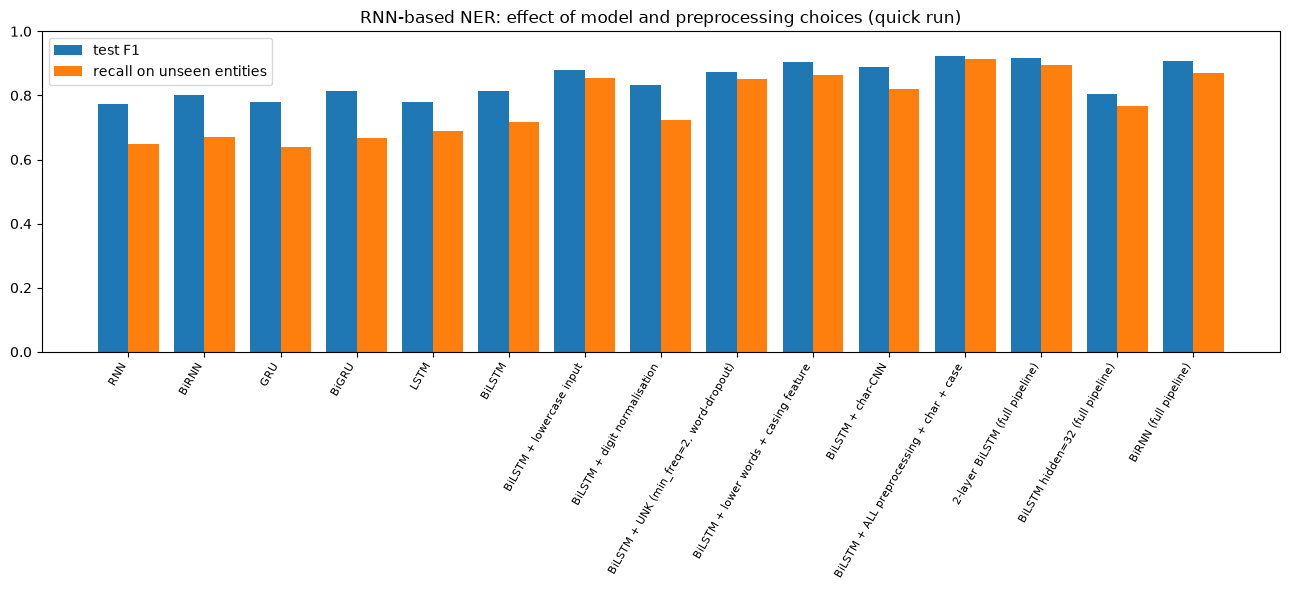


Test F1 per configuration: this run (quick) vs earlier run in lab 4/solution/results/ (read-only)


configuration,F1 this run (quick),F1 earlier run
RNN,0.774,0.828
BiRNN,0.800,0.882
GRU,0.779,0.822
BiGRU,0.815,0.874
LSTM,0.780,0.845
BiLSTM,0.814,0.877
BiLSTM + lowercase input,0.880,0.913
BiLSTM + digit normalisation,0.832,0.919
"BiLSTM + UNK (min_freq=2, word-dropout)",0.874,0.900
BiLSTM + lower words + casing feature,0.904,0.917


In [7]:
import csv
all_recs = results_records()
display(html_table(COLS, pick(all_recs, COLS)))

csv_path = OUT_DIR / f"experiments_{MODE}.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(COLS)
    for r in pick(all_recs, COLS):
        w.writerow([round(x, 4) if isinstance(x, float) else x for x in r])
print(f"Saved table -> {csv_path}")

names = [c["name"] for c, _ in rows]
x = np.arange(len(rows))
fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - 0.2, [r["F1"] for _, r in rows], 0.4, label="test F1")
ax.bar(x + 0.2, [r["R_unseen"] for _, r in rows], 0.4, label="recall on unseen entities")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=60, ha="right", fontsize=8)
ax.set_ylim(0, 1)
ax.set_title(f"RNN-based NER: effect of model and preprocessing choices ({MODE} run)")
ax.legend()
fig.tight_layout()
png_path = OUT_DIR / f"experiments_{MODE}.png"
fig.savefig(png_path, dpi=130)
print(f"Saved chart -> {png_path}")
plt.show()

ref_path = SOL / "results" / "experiments.csv"          # read-only: earlier run, for comparison
with open(ref_path, encoding="utf-8") as f:
    ref = {row["configuration"]: float(row["f1"]) for row in csv.DictReader(f)}
print(f"\nTest F1 per configuration: this run ({MODE}) vs earlier run in lab 4/solution/results/ (read-only)")
display(html_table(["configuration", f"F1 this run ({MODE})", "F1 earlier run"],
                   [[c["name"], r["F1"], ref.get(c["name"], float("nan"))] for c, r in rows]))

## 6. Best model: per-type report, confusion matrix and error taxonomy

The best model is the configuration with the highest dev F1 (the same rule as the script). The per-type table is
entity-level (exact span and type). The seqeval report is an independent cross-check. The error taxonomy assigns
each gold entity to *correct*, *type error* (same span, wrong type), *boundary error* (overlapping span) or
*missed*, and each predicted entity without any overlap to *spurious*.

In [8]:
cfg, res, preds = best["cfg"], best["res"], best["preds"]
print(f"Best model by dev F1: {cfg['name']}   (dev F1 {res['dev_F1']:.4f}, best epoch {res['best_epoch']})\n")

type_rows = [[t, p, r_, f, int(s)] for t, (p, r_, f, s) in res["per_type"].items()]
type_rows.append(["micro", res["P"], res["R"], res["F1"], sum(int(v[3]) for v in res["per_type"].values())])
display(html_table(["entity", "precision", "recall", "F1", "support"], type_rows))
print(f"macro-F1 {res['macroF1']:.3f} | token accuracy {res['tok_acc']:.3f}")

try:
    from seqeval.metrics import classification_report
    print("\nseqeval cross-check (span-level):")
    print(classification_report([g for _, g in test], preds, digits=3, zero_division=0))
except ImportError:
    print("(seqeval not installed)")

Best model by dev F1: 2-layer BiLSTM (full pipeline)   (dev F1 0.9280, best epoch 5)



entity,precision,recall,F1,support
DATE,0.996,0.989,0.992,261
LOC,0.956,0.990,0.973,288
ORG,0.778,0.883,0.827,266
PER,0.941,0.809,0.870,257
micro,0.913,0.920,0.916,"1,072"


macro-F1 0.916 | token accuracy 0.963



seqeval cross-check (span-level):


              precision    recall  f1-score   support

        DATE      0.996     0.989     0.992       261
         LOC      0.956     0.990     0.973       288
         ORG      0.778     0.883     0.827       266
         PER      0.941     0.809     0.870       257

   micro avg      0.913     0.920     0.916      1072
   macro avg      0.918     0.918     0.916      1072
weighted avg      0.918     0.920     0.917      1072



In [9]:
cm = Counter((g, p) for (_, gs), ps in zip(test, preds) for g, p in zip(gs, ps))
print("Token-level confusion matrix (rows = gold, columns = predicted):")
display(html_table(["gold \\ pred"] + tags,
                   [[g] + [cm[(g, p)] for p in tags] for g in tags], digits=0))

tax = error_taxonomy(test, preds)
print("\nEntity-level error taxonomy:")
display(html_table(["category", "count"], tax.most_common()))

print("\nSample errors (first 6 test sentences with any mismatch):")
shown = 0
for (toks, gold), pred in zip(test, preds):
    if gold != pred and shown < 6:
        shown += 1
        print("  " + " ".join(toks))
        print("     gold: " + (", ".join(f"{' '.join(toks[s:e + 1])}<{t}>" for t, s, e in get_entities(gold)) or "(none)"))
        print("     pred: " + (", ".join(f"{' '.join(toks[s:e + 1])}<{t}>" for t, s, e in get_entities(pred)) or "(none)"))

Token-level confusion matrix (rows = gold, columns = predicted):


gold \ pred,O,B-DATE,I-DATE,B-LOC,I-LOC,B-ORG,I-ORG,B-PER,I-PER
O,"2,304",1,0,0,0,23,8,0,0
B-DATE,0,256,2,2,1,0,0,0,0
I-DATE,0,0,240,0,0,0,0,0,0
B-LOC,0,0,0,288,0,0,0,0,0
I-LOC,2,0,0,0,21,0,0,0,0
B-ORG,14,0,0,7,0,244,1,0,0
I-ORG,0,0,0,0,1,8,175,0,0
B-PER,9,0,0,1,0,22,7,218,0
I-PER,12,0,0,0,0,1,24,3,158



Entity-level error taxonomy:


category,count
correct,986
boundary error (overlapping span),43
"type error (right span, wrong type)",32
spurious entity (false positive),18
missed entity (false negative),11



Sample errors (first 6 test sentences with any mismatch):
  A delegation from Apex Airlines met Ravi Tanaka in Coimbatore
     gold: Apex Airlines<ORG>, Ravi Tanaka<PER>, Coimbatore<LOC>
     pred: Apex Airlines<ORG>, Ravi Tanaka<ORG>, Coimbatore<LOC>
  A delegation from IBM met Imran Williams in Chandigarh
     gold: IBM<ORG>, Imran Williams<PER>, Chandigarh<LOC>
     pred: IBM<LOC>, Imran Williams<ORG>, Chandigarh<LOC>
  Professor John left Qatar Airways after ten years
     gold: John<PER>, Qatar Airways<ORG>
     pred: Professor John<ORG>, Qatar Airways<ORG>
  reserve bank of india announced a new office in bangalore on today
     gold: reserve bank of india<ORG>, bangalore<LOC>, today<DATE>
     pred: bank of india<ORG>, bangalore<LOC>, today<DATE>
  real madrid opened its largest store in bhutan
     gold: real madrid<ORG>, bhutan<LOC>
     pred: madrid<ORG>, bhutan<LOC>
  a delegation from redstone motors met arun verma in cairo
     gold: redstone motors<ORG>, arun verma<PER>,

## 7. `--text` demo

The best model tags a custom sentence, tokenised with the same regex as `rnn_ner.py --text`. The sentence is not
from the synthetic corpus, and the year 2027 is outside the training years, so this is an out-of-distribution check.

In [10]:
SENT = "Sundar Pichai visited Chennai on 5 March 2027"
toks = re.findall(r"[A-Za-z0-9'&.-]+|[^\sA-Za-z0-9]", SENT)
tag2idx, idx2tag = best["maps"]
pred_tags = predict(best["model"], best["pre"], [(toks, ["O"] * len(toks))], tag2idx, idx2tag)[0]

print(f"Sentence: {SENT}   (model: {best['cfg']['name']})")
display(html_table(["#", "token", "predicted tag"], [[i, w, t] for i, (w, t) in enumerate(zip(toks, pred_tags))]))
ents = [(" ".join(toks[s:e + 1]), t) for t, s, e in get_entities(pred_tags)]
print("entities: " + (", ".join(f"{s}<{t}>" for s, t in ents) if ents else "(none)"))

Sentence: Sundar Pichai visited Chennai on 5 March 2027   (model: 2-layer BiLSTM (full pipeline))


#,token,predicted tag
0,Sundar,B-PER
1,Pichai,I-PER
2,visited,O
3,Chennai,B-ORG
4,on,O
5,5,B-DATE
6,March,I-DATE
7,2027,I-DATE


entities: Sundar Pichai<PER>, Chennai<ORG>, 5 March 2027<DATE>


## Notes / what to look for

Numbers are from the executed notebook in **quick mode** (800 / 200 / 400 sentences, 6 epochs, seed 7, one run each).

- **Bidirectionality** is the clearest architecture effect: BiLSTM-LSTM +0.034, BiGRU-GRU +0.036, BiRNN-RNN +0.026 test F1.
- **Gated vs vanilla RNN** is small here: LSTM-RNN +0.006 (helped) and GRU-RNN +0.005 (no clear difference by the 0.005 threshold). Sentences average 10 tokens, where gating matters less.
- **Preprocessing** gives the largest gains. Plain BiLSTM 0.814 F1 (unseen-entity recall 0.718). Casing feature with lower-cased words 0.904 (+0.090); char-CNN 0.888 (+0.074); lower-casing alone 0.880 (+0.066); `<UNK>` handling 0.874 (+0.060, unseen recall 0.852); digit normalisation 0.832 (+0.018). All combined: 0.923 F1 (+0.110), unseen recall 0.913.
- **Capacity**: the 2-layer BiLSTM gives 0.916 (-0.007 vs the combined BiLSTM), hidden=32 gives 0.803 (-0.120), BiRNN cell gives 0.908 (-0.015). Depth does not help once the input features are good; a small hidden size under-fits.
- **Model selection**: the 2-layer model has the best dev F1 (0.928) and is therefore the "best model", but its test F1 (0.916) is below the combined BiLSTM (0.923). This dev/test gap is about 0.01, so one seed cannot separate the two.
- **Per-type errors (best model)**: DATE F1 0.992, LOC 0.973, PER 0.870 (recall 0.809), ORG 0.827 (precision 0.778). ORG/PER confusions dominate the confusion matrix. Entity taxonomy: 986 correct, 43 boundary, 32 type, 18 spurious, 11 missed.
- **Unseen entities**: 621 of 1,072 test entity mentions (57.9 %) never appear in training, so recall on unseen entities is the key number to watch.
- **--text demo**: "Sundar Pichai" is PER and "5 March 2027" is DATE, but "Chennai" is tagged ORG rather than LOC. The model is small and trained on synthetic data.
- **Comparison with the earlier full run** (read-only, `lab 4/solution/results/`): every configuration scores 0.013 to 0.119 F1 lower here. This is consistent with less data and fewer epochs, but it was not tested separately.
- **Full run**: set `RUN_FULL = True` in the setup cell and Run All (about 20-30 min on CPU). Outputs go to `notebooks/lab4_outputs/`, so `results/` is unchanged.